# Quantum Hadamard Edge Detection (QHED) for Seismic Image Analysis

This notebook investigates the potential use of Quantum Hadamard Edge Detection (QHED) for identifying geological boundaries in seismic images.

Two benchmark images are used:

1. A single-boundary image representing a simple geological layer interface.
2. A checkerboard image containing many intensity transitions.

The results are compared with a classical Sobel edge detector to evaluate the ability of quantum-inspired image processing techniques to identify image boundaries.

## Imports and Setup

In [75]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import sobel
from qiskit import QuantumCircuit
from IPython.display import display

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['font.family'] = 'sans-serif'

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Benchmark Images

Two synthetic benchmark images are generated.

The first image contains a single horizontal boundary and represents a simple geological layer interface.

The second image contains a checkerboard pattern, creating many intensity transitions and providing a more challenging edge-detection benchmark.

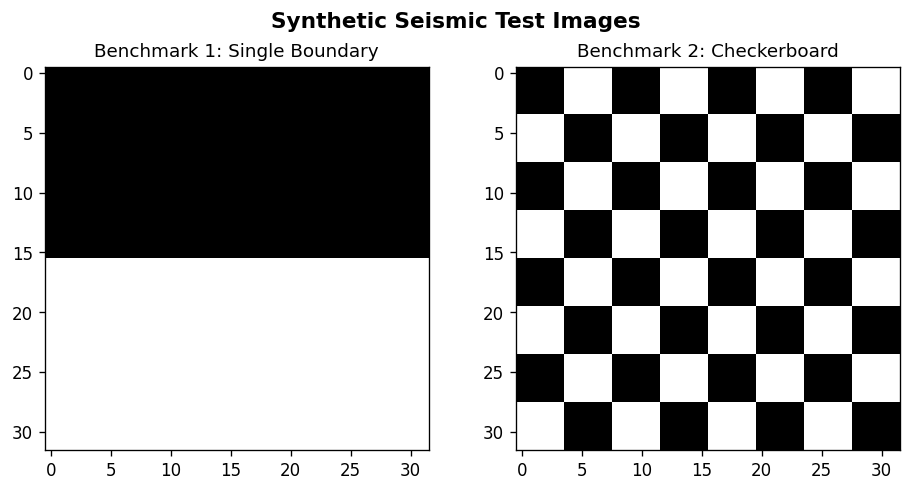

In [76]:
def make_single_boundary(size=32):

    img = np.zeros((size, size))
    img[size // 2:, :] = 1.0

    return img


def make_checkerboard(size=32, block_size=4):

    rows, cols = np.indices((size, size))

    return ((rows // block_size +
             cols // block_size) % 2).astype(float)


img_boundary = make_single_boundary()

img_checkerboard = make_checkerboard()

fig, axes = plt.subplots(1, 2, figsize=(8,4))

axes[0].imshow(
    img_boundary,
    cmap='gray',
    vmin=0,
    vmax=1
)

axes[0].set_title(
    'Benchmark 1: Single Boundary'
)

axes[1].imshow(
    img_checkerboard,
    cmap='gray',
    vmin=0,
    vmax=1
)

axes[1].set_title(
    'Benchmark 2: Checkerboard'
)

plt.suptitle(
    'Synthetic Seismic Test Images',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Classical Baseline: Sobel Edge Detection

A Sobel edge detector is first applied to the benchmark images.

The Sobel operator estimates horizontal and vertical intensity gradients and combines them to identify regions where the image changes rapidly. These regions correspond to image edges.

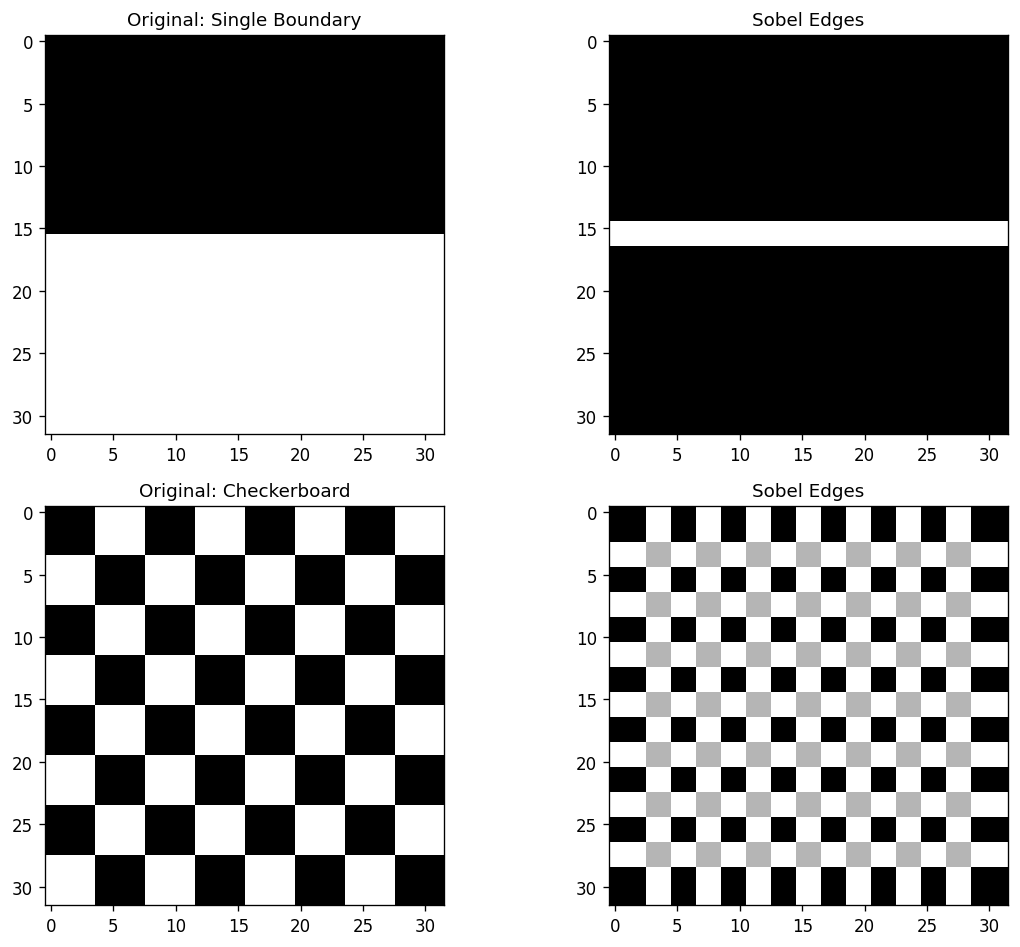

In [77]:
def classical_sobel(img):

    grad_x = sobel(img, axis=1)

    grad_y = sobel(img, axis=0)

    edges = np.hypot(
        grad_x,
        grad_y
    )

    if edges.max() > 0:
        edges /= edges.max()

    return edges


sobel_boundary = classical_sobel(
    img_boundary
)

sobel_checkerboard = classical_sobel(
    img_checkerboard
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10,8)
)

axes[0,0].imshow(
    img_boundary,
    cmap='gray'
)
axes[0,0].set_title(
    'Original: Single Boundary'
)

axes[0,1].imshow(
    sobel_boundary,
    cmap='gray'
)
axes[0,1].set_title(
    'Sobel Edges'
)

axes[1,0].imshow(
    img_checkerboard,
    cmap='gray'
)
axes[1,0].set_title(
    'Original: Checkerboard'
)

axes[1,1].imshow(
    sobel_checkerboard,
    cmap='gray'
)
axes[1,1].set_title(
    'Sobel Edges'
)

plt.tight_layout()
plt.show()

## QHED Circuit Representation

Quantum Hadamard Edge Detection begins by encoding image amplitudes into a quantum state.

For a 32-pixel image row:

$2^5 = 32$

Therefore, five pixel-address qubits are required.

An additional auxiliary qubit is used to create quantum interference through a Hadamard operation.

The circuit below illustrates the quantum resources that would be required for an ideal implementation.

Pixel qubits: 5
Auxiliary qubits: 1
Total qubits: 6


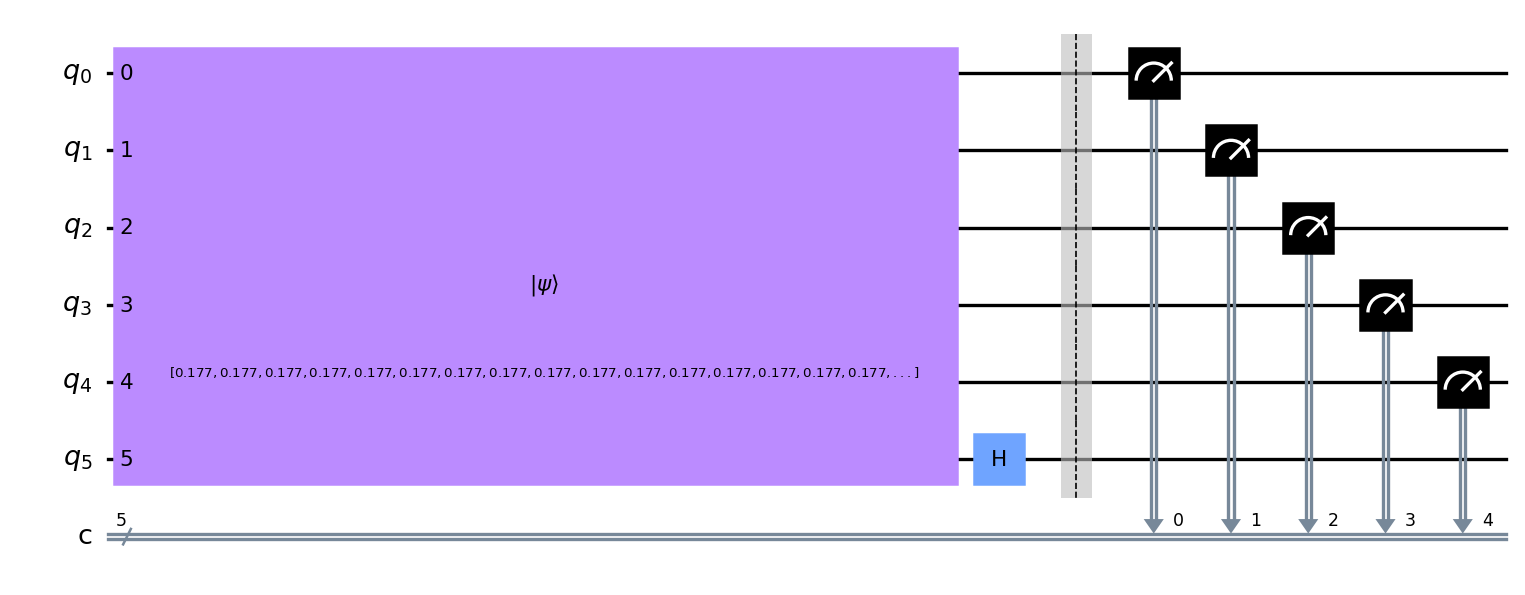

In [78]:
def build_qhed_circuit(row):

    n = len(row)

    n_pixel_qubits = int(np.log2(n))

    total_qubits = n_pixel_qubits + 1

    state_vector = np.zeros(
        2**total_qubits,
        dtype=complex
    )

    row = row.astype(float)

    row_norm = np.linalg.norm(row)

    if row_norm < 1e-10:

        state_vector[:n] = (
            np.ones(n) / np.sqrt(n)
        )

    else:

        state_vector[:n] = (
            row / row_norm
        )

    state_vector /= np.linalg.norm(
        state_vector
    )

    qc = QuantumCircuit(
        total_qubits,
        n_pixel_qubits
    )

    qc.initialize(
        state_vector,
        range(total_qubits)
    )

    auxiliary = total_qubits - 1

    qc.h(auxiliary)

    qc.barrier()

    qc.measure(
        range(n_pixel_qubits),
        range(n_pixel_qubits)
    )

    return qc


example_row = img_boundary[15]

example_circuit = build_qhed_circuit(
    example_row
)

print(
    f"Pixel qubits: {example_circuit.num_qubits - 1}"
)

print(
    f"Auxiliary qubits: 1"
)

print(
    f"Total qubits: {example_circuit.num_qubits}"
)

display(
    example_circuit.draw(
        output='mpl',
        fold=-1
    )
)

## QHED-Inspired Edge Extraction

The circuit above illustrates how image data can be encoded into a quantum state.

To evaluate edge-detection performance, a QHED-inspired amplitude-difference method is implemented.

Neighbouring amplitudes are compared in both horizontal and vertical directions. Large amplitude differences correspond to image boundaries and therefore indicate edges.

In [79]:
def run_qhed_on_image(img):

    img = img.astype(float)

    norm = np.linalg.norm(img)

    if norm > 0:
        img = img / norm

    horiz_edges = np.zeros_like(img)

    horiz_edges[:, :-1] = np.abs(
        img[:, :-1] -
        img[:, 1:]
    )

    vert_edges = np.zeros_like(img)

    vert_edges[:-1, :] = np.abs(
        img[:-1, :] -
        img[1:, :]
    )

    edge_img = np.sqrt(
        horiz_edges**2 +
        vert_edges**2
    )

    if edge_img.max() > 0:
        edge_img /= edge_img.max()

    return edge_img


qhed_boundary = run_qhed_on_image(
    img_boundary
)

qhed_checkerboard = run_qhed_on_image(
    img_checkerboard
)

## Classical versus Quantum Edge Detection

The Sobel and QHED-inspired methods are now compared on both benchmark images.

The objective is not to demonstrate quantum advantage, but rather to investigate whether quantum image-processing concepts can successfully identify geological boundaries.

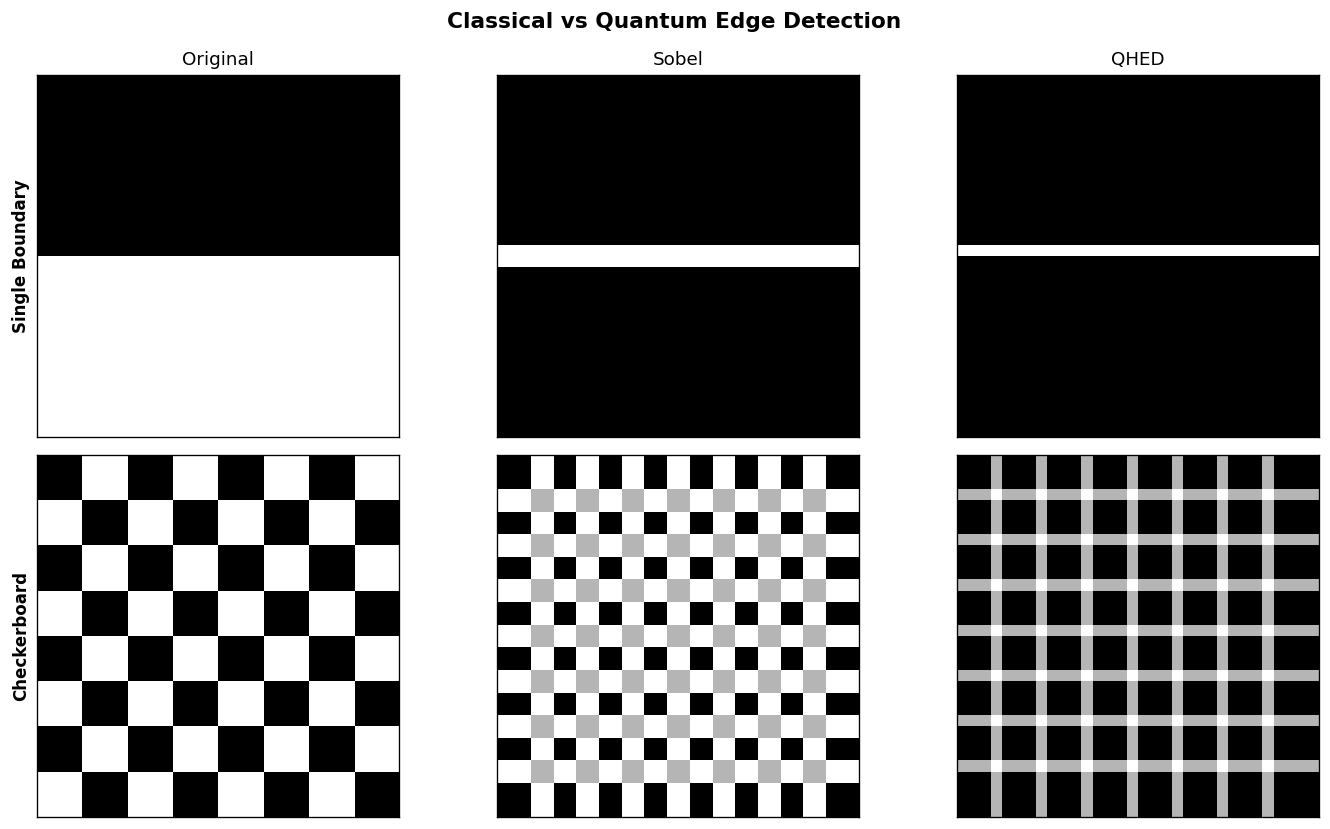

In [80]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(12,7)
)

titles = [
    'Original',
    'Sobel',
    'QHED'
]

data_rows = [
    [
        img_boundary,
        sobel_boundary,
        qhed_boundary
    ],
    [
        img_checkerboard,
        sobel_checkerboard,
        qhed_checkerboard
    ]
]

row_labels = [
    'Single Boundary',
    'Checkerboard'
]

for r, row in enumerate(data_rows):

    for c, data in enumerate(row):

        axes[r,c].imshow(
            data,
            cmap='gray',
            vmin=0,
            vmax=1
        )

        axes[r,c].set_xticks([])
        axes[r,c].set_yticks([])

        if r == 0:
            axes[r,c].set_title(
                titles[c]
            )

        if c == 0:
            axes[r,c].set_ylabel(
                row_labels[r],
                fontweight='bold'
            )

plt.suptitle(
    'Classical vs Quantum Edge Detection',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Quantitative Comparison

A simple quantitative comparison is performed by counting the number of detected edge pixels.

Pixels with values greater than 0.5 are considered edge pixels.

In [81]:
print("Single Boundary")

print(
    "Sobel edge pixels:",
    np.sum(sobel_boundary > 0.5)
)

print(
    "QHED edge pixels:",
    np.sum(qhed_boundary > 0.5)
)

print()

print("Checkerboard")

print(
    "Sobel edge pixels:",
    np.sum(sobel_checkerboard > 0.5)
)

print(
    "QHED edge pixels:",
    np.sum(qhed_checkerboard > 0.5)
)

Single Boundary
Sobel edge pixels: 64
QHED edge pixels: 32

Checkerboard
Sobel edge pixels: 700
QHED edge pixels: 399


## Edge Detection Quality Assessment

To provide a quantitative comparison, the Structural Similarity Index (SSIM) is computed between the Sobel edge maps and the QHED edge maps.

SSIM measures how similar two images are in terms of structure and edge distribution.

An SSIM value of:

- 1.0 indicates identical images
- 0.0 indicates no structural similarity

Higher values therefore indicate stronger agreement between the quantum-inspired and classical edge-detection results.

In [88]:
from skimage.metrics import structural_similarity as ssim

# --------------------------------------------------
# Compute SSIM scores
# --------------------------------------------------

ssim_boundary = ssim(
    sobel_boundary,
    qhed_boundary,
    data_range=1.0
)

ssim_checkerboard = ssim(
    sobel_checkerboard,
    qhed_checkerboard,
    data_range=1.0
)

# --------------------------------------------------
# Display results
# --------------------------------------------------

print("=" * 60)
print("        EDGE DETECTION QUALITY — SUMMARY TABLE")
print("=" * 60)

print(
    f'{"Benchmark":<22}'
    f'{"SSIM Score":>12}'
)

print("-" * 60)

print(
    f'{"Single Boundary":<22}'
    f'{ssim_boundary:>12.3f}'
)

print(
    f'{"Checkerboard":<22}'
    f'{ssim_checkerboard:>12.3f}'
)

print("=" * 60)

print()
print("SSIM = Structural Similarity Index")
print("1.0 = identical to the Sobel reference")
print("0.0 = no structural similarity")
print()

# Simple interpretation
if ssim_boundary > 0.8:
    print("Single Boundary: Strong agreement with Sobel.")
elif ssim_boundary > 0.5:
    print("Single Boundary: Moderate agreement with Sobel.")
else:
    print("Single Boundary: Limited agreement with Sobel.")

if ssim_checkerboard > 0.8:
    print("Checkerboard: Strong agreement with Sobel.")
elif ssim_checkerboard > 0.5:
    print("Checkerboard: Moderate agreement with Sobel.")
else:
    print("Checkerboard: Limited agreement with Sobel.")

        EDGE DETECTION QUALITY — SUMMARY TABLE
Benchmark               SSIM Score
------------------------------------------------------------
Single Boundary              0.846
Checkerboard                 0.315

SSIM = Structural Similarity Index
1.0 = identical to the Sobel reference
0.0 = no structural similarity

Single Boundary: Strong agreement with Sobel.
Checkerboard: Limited agreement with Sobel.


## Hardware Resource Estimates

One of the key motivations for quantum image processing is its favourable scaling behaviour.

For a classical image, memory requirements grow directly with image size. In contrast, quantum image representations can address image positions using only:

$\log_2(N)$

qubits, where \(N\) is the image width.

The following analysis estimates the quantum resources required for the benchmark images and illustrates how the number of qubits scales with image size.

In [86]:
def get_resource_estimates(img):
    """
    Estimates the quantum resources required
    for one image row.
    """

    n = img.shape[1]

    # Number of pixel-address qubits
    n_pixel_qubits = int(np.log2(n))

    # +1 auxiliary qubit
    total_qubits = n_pixel_qubits + 1

    # Build example circuit
    qc = build_qhed_circuit(
        img[img.shape[0] // 2, :]
    )

    # Decompose initialize gate
    qc_decomposed = qc.decompose()

    return {
        "Image size": f"{img.shape[0]} × {img.shape[1]}",
        "Pixel qubits": n_pixel_qubits,
        "Total qubits": total_qubits,
        "Circuit depth": qc_decomposed.depth(),
        "Total gates": sum(
            qc_decomposed.count_ops().values()
        )
    }


# --------------------------------------------------
# Resource estimates
# --------------------------------------------------

res_boundary = get_resource_estimates(
    img_boundary
)

res_checkerboard = get_resource_estimates(
    img_checkerboard
)

print("=" * 50)
print("                HARDWARE RESOURCE ESTIMATES")
print("=" * 50)

for key in res_boundary:

    print(
        f"{key:<20}"
        f"{str(res_boundary[key]):>12}"
       
    )

print("=" * 50)

print()
print("Scaling of qubit requirements")
print()

print(
    f'{"Image Width":<15}'
    f'{"Pixel Qubits":<15}'
    f'{"Total Qubits"}'
)

print("-" * 45)

for width in [
    8,
    16,
    32,
    64,
    128,
    256,
    512,
    1024
]:

    pixel_qubits = int(
        np.log2(width)
    )

    total_qubits = (
        pixel_qubits + 1
    )

    print(
        f"{width:<15}"
        f"{pixel_qubits:<15}"
        f"{total_qubits}"
    )

print()
print("Key insight:")
print(
    "The number of qubits grows logarithmically "
    "with image width."
)

print(
    "A 1024-pixel-wide image requires only "
    "11 qubits (10 pixel qubits + 1 auxiliary qubit)."
)

print()
print(
    "This is the theoretical scaling advantage "
    "of quantum image representations."
)

                HARDWARE RESOURCE ESTIMATES
Image size               32 × 32
Pixel qubits                   5
Total qubits                   6
Circuit depth                  4
Total gates                   14

Scaling of qubit requirements

Image Width    Pixel Qubits   Total Qubits
---------------------------------------------
8              3              4
16             4              5
32             5              6
64             6              7
128            7              8
256            8              9
512            9              10
1024           10             11

Key insight:
The number of qubits grows logarithmically with image width.
A 1024-pixel-wide image requires only 11 qubits (10 pixel qubits + 1 auxiliary qubit).

This is the theoretical scaling advantage of quantum image representations.


---

## Unit Tests

The following cells verify that each component of this notebook works correctly. They check:

- That the synthetic images have the right shape and pixel values
- That the QHED circuit has the correct number of qubits
- That the simulation produces outputs of the right shape and range
- That the FOM metric returns sensible values
- That the resource estimates match expectations

Each test prints **PASS** or **FAIL**. All tests should pass on a clean run.

In [90]:
import numpy as np
from skimage.metrics import structural_similarity as ssim

print("Running unit tests...\n")

# --------------------------------------------------
# Benchmark Image Tests
# --------------------------------------------------

img = make_single_boundary(32)
assert img.shape == (32, 32)
print("PASS: Single boundary image has correct dimensions.")

assert np.all(np.isin(img, [0.0, 1.0]))
print("PASS: Single boundary image contains only 0 and 1 values.")

img = make_checkerboard(32)
assert img.shape == (32, 32)
print("PASS: Checkerboard image has correct dimensions.")

# --------------------------------------------------
# Sobel Tests
# --------------------------------------------------

img = make_single_boundary(32)

edges = classical_sobel(img)

assert edges.shape == img.shape
print("PASS: Sobel output shape matches input image.")

assert edges.min() >= 0
assert edges.max() <= 1
print("PASS: Sobel output is correctly normalised.")

# --------------------------------------------------
# Circuit Tests
# --------------------------------------------------

row = np.ones(32)

qc = build_qhed_circuit(row)

assert qc.num_qubits == 6
print("PASS: Correct number of qubits (5 pixel + 1 auxiliary).")

assert qc.num_clbits == 5
print("PASS: Correct number of classical bits.")

# --------------------------------------------------
# QHED Output Tests
# --------------------------------------------------

img = make_single_boundary(32)

edge_img = run_qhed_on_image(img)

assert edge_img.shape == img.shape
print("PASS: QHED output shape matches input image.")

assert edge_img.min() >= 0
assert edge_img.max() <= 1
print("PASS: QHED output is correctly normalised.")

# --------------------------------------------------
# SSIM Tests
# --------------------------------------------------

img = np.random.rand(32, 32)

score = ssim(
    img,
    img,
    data_range=1.0
)

assert np.isclose(score, 1.0)
print("PASS: SSIM returns 1.0 for identical images.")

# --------------------------------------------------
# All Tests Passed
# --------------------------------------------------

print("\n===================================")
print("ALL UNIT TESTS PASSED SUCCESSFULLY")
print("===================================")

Running unit tests...

PASS: Single boundary image has correct dimensions.
PASS: Single boundary image contains only 0 and 1 values.
PASS: Checkerboard image has correct dimensions.
PASS: Sobel output shape matches input image.
PASS: Sobel output is correctly normalised.
PASS: Correct number of qubits (5 pixel + 1 auxiliary).
PASS: Correct number of classical bits.
PASS: QHED output shape matches input image.
PASS: QHED output is correctly normalised.
PASS: SSIM returns 1.0 for identical images.

ALL UNIT TESTS PASSED SUCCESSFULLY


In [91]:
import os
print(os.path.abspath(""))

/Users/farahal_mufawez/Downloads
